# Active object tracking with invisible spectral ink

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cubert-hyperspectral/cuvis-ai/blob/main/notebooks/use_cases/object_tracking_active.ipynb)

When a target is sprayed with a near-infrared-fluorescent ink, it becomes
**invisible to the naked eye and to any RGB sensor** but **bright in a tuned
spectral band**. Tracking such a marker is fundamentally different from passive
tracking with SAM3 (Meta's Segment Anything Model 3): there is no model, no
training, and no drift — every frame is decided by a per-pixel spectral-angle
test against a precomputed ink prototype.

This notebook builds a Cuvis.AI pipeline that

1. computes a **SPAM (Spectral Angle Mapper)** score per pixel against the ink
   reference,
2. thresholds + cleans it into a robust mask,
3. burns a coloured highlight onto a CIE-tristimulus RGB rendering, and
4. derives a **Kalman-smoothed bounding box** that is cropped, zoomed, and
   composited back onto the highlight frame as a picture-in-picture inset —
   one tracking video, no second file.

**Pipeline at a glance:**

```
CU3SDataNode ─┬─► CIETristimulusRGBSelector ──► MaskOverlayNode ──┬─► InsetComposer ──► ToVideoNode  (tracking.mp4)
              │                                       ▲           │       ▲
              ├─► BandpassByWavelength(cube) ─► SPAM ─┤           │       │
              │                                       │           └─► ROIZoomNode
              └─► BandpassByWavelength(signature) ────┘                   ▲
                              ▲                                           │
                  NpyReader (ink prototype)                  MaskToBBoxKalman
                                                                          ▲
        BinaryDecider ──► DecisionToMask ──► MaskRobustifier ─────────────┘
```

This notebook is the deep-dive companion to
[`object_tracking_passive.ipynb`](./object_tracking_passive.ipynb), which covers the
passive (SAM3-based) tracking modes.

> **Prerequisites**
>
> 1. Install cuvis-ai — see the [Installation Guide](https://docs.cuvis.ai/latest/user-guide/installation/).
> 2. From the cuvis-ai env, launch the notebook with `uv run jupyter lab`.

In [ ]:
# Colab bootstrap — no-op when running locally
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q cuvis-ai
    !which ffmpeg dot >/dev/null || echo "WARN: ffmpeg/dot missing on this runtime"

    import torch

    if not torch.cuda.is_available():
        print(
            "WARNING: No GPU detected. Switch via Runtime > Change runtime type > T4 GPU. "
            "CPU runs are slow (perfusion ~10x, SAM3 passive ~80x)."
        )

In [1]:
# ruff: noqa: E402
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from cuvis_ai_dataloader.data import SingleCu3sDataModule
from IPython.display import Image, Video, display
from loguru import logger

from cuvis_ai.node.anomaly_visualization import MaskOverlayNode
from cuvis_ai.node.channel_selector import CIETristimulusRGBSelector, NormMode
from cuvis_ai.node.compositing import InsetComposer, ROIZoomNode
from cuvis_ai.node.conversion import DecisionToMask, ScoreToLogit
from cuvis_ai.node.data import CU3SDataNode
from cuvis_ai.node.deciders.binary_decider import BinaryDecider
from cuvis_ai.node.mask_ops import MaskRobustifier, MaskToBBoxKalman
from cuvis_ai.node.numpy_file import NpyReader
from cuvis_ai.node.preprocessors import BandpassByWavelength
from cuvis_ai.node.spectral_angle_mapper import SpectralAngleMapper
from cuvis_ai.node.video import ToVideoNode
from cuvis_ai.utils.false_rgb_sampling import initialize_false_rgb_sampled_fixed
from cuvis_ai.utils.xml_plugin_parser import read_xml_inputs
from cuvis_ai_core.data.public_datasets import PublicDatasets
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor

In [2]:
device = torch.device("cpu")
# Pick the best available torch device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
logger.info(f"Using device {device}")

2026-04-30 11:03:32.473 | INFO     | __main__:<module>:7 - Using device cuda


## 1 · Fetch the dataset

The XMR Object Tracking dataset (~25 GB) lives on Hugging Face Hub. This
notebook uses only the **active session**, where one actor sprays the target
with NIR-fluorescent ink mid-recording.

| Session | Folder | Scene |
|---------|--------|-------|
| **Active** | `2026_04_20_16_28_54` | Three actors in identical outfits; mid-clip one of them is sprayed with invisible ink. The marker is undetectable in RGB but lights up in a narrow NIR band. |

The session folder also ships an `spam-overlay-rgb.xml` plugin file containing
the precomputed ink reference spectrum and the spectral-angle threshold — we
parse those values directly in §4.

In [3]:
dataset_dir = Path("/content/data") if IN_COLAB else Path("../../data")

_ = PublicDatasets.download_dataset(
    "demo_object_tracking",
    download_path=str(dataset_dir),
    force=False,
)

Dataset 'demo_object_tracking' already exists at ..\..\data\XMR_Demo_Object_Tracking
Use force=True to re-download.


## 2 · How SPAM (Spectral Angle Mapper) works

Each pixel of a hyperspectral cube is a vector $\mathbf{p} \in \mathbb{R}^{C}$
(one entry per band). The ink prototype is another such vector
$\mathbf{r} \in \mathbb{R}^{C}$. The **spectral angle**

$$
\theta(\mathbf{p}, \mathbf{r}) \;=\;
\arccos\!\left(
\frac{\mathbf{p} \cdot \mathbf{r}}{\lVert \mathbf{p} \rVert\, \lVert \mathbf{r} \rVert}
\right)
$$

is the angle between the two vectors — small $\theta$ means *similar spectral
shape*, regardless of overall brightness. That brightness-invariance is the
property that makes SPAM robust to lighting changes and shadows: a marker in
shade and a marker in sun produce the same angle, even though their absolute
radiance values differ by an order of magnitude.

Compared to SAM3 (Meta's segmentation model used in
[`uc_object_tracking.ipynb`](./uc_object_tracking.ipynb)):

| Property | SAM3 mask propagation | SPAM (this notebook) |
|----------|-----------------------|----------------------|
| Requires training / fine-tuning | No (pre-trained) | No |
| Reference data needed | One seed mask | 1 spectrum vector |
| Works without ink | Yes | No (needs a marked target) |
| Fails on visually ambiguous targets | Sometimes | No (spectral, not appearance) |
| Robust to occlusion | Drift possible | Re-acquires on reappearance |
| Latency | Tracker-bound | Millisecond, deterministic |

## 3 · Tutorial configuration

Edit these variables to customise the run.

- **`PROCESSING_MODE`** — `"SpectralRadiance"` is correct for this dataset; no
  white reference was recorded, so reflectance calibration is not possible.
- **`SAM_THRESHOLD_OVERRIDE`** — when not `None`, replaces the threshold parsed
  from the XML. Lower ⇒ more permissive (more pixels declared "ink"). Higher
  ⇒ tighter mask.
- **`OVERLAY_COLOR`** — RGB triplet in [0, 1] for the highlight burn.
- **`ZOOM_SIZE`** — edge length (px) of the square zoom-inset video.
- **`ROBUST_MIN_AREA`** — drop mask connected components with fewer pixels.
- **`KALMAN_MIN_HITS`** — measurement frames required to confirm a new ROI
  track (suppresses transient false positives).
- **`KALMAN_MAX_PREDICT`** — after this many empty frames, drop the track.
- **`PREVIEW_END_FRAME`** — first slice for §8; the full clip is run in §11.
- **`FRAME_RATE`** — output video FPS (matches the sensor capture rate).

In [4]:
PROCESSING_MODE = "SpectralRadiance"

SAM_THRESHOLD_OVERRIDE: float | None = None  # set e.g. 0.95 to override XML
OVERLAY_ALPHA = 1.0
OVERLAY_COLOR = (1.0, 0.0, 0.0)

# Picture-in-picture inset placement (composited onto the overlay frame).
ZOOM_SIZE = 320
INSET_CORNER = "top-right"  # one of: top-left, top-right, bottom-left, bottom-right
INSET_MARGIN_PX = 16
INSET_BORDER_PX = 2
INSET_BORDER_COLOR = (1.0, 1.0, 1.0)

ROBUST_OPENING = 0
ROBUST_MIN_AREA = 10
KALMAN_MIN_HITS = 3
KALMAN_MAX_PREDICT = 20

PREVIEW_END_FRAME = 200
FRAME_RATE = 15.0

dataset_dir = Path("/content/data") if IN_COLAB else Path("../../data")
output_dir = Path("./output/object_tracking_active")
output_dir.mkdir(parents=True, exist_ok=True)

active_cu3s = (
    dataset_dir
    / "XMR_Demo_Object_Tracking"
    / "measurements"
    / "cu3s"
    / "2026_04_20_16_28_54"
    / "Auto_000.cu3s"
)
sam_xml_path = active_cu3s.parent / "spam-overlay-rgb.xml"

tracking_video_path = output_dir / "tracking.mp4"
ink_reference_npy = output_dir / "ink_reference.npy"

print(f"Active CU3S:        {active_cu3s}")
print(f"SAM XML:            {sam_xml_path}")
print(f"Tracking video:     {tracking_video_path}")
print(f"Ink reference NPY:  {ink_reference_npy}")

Active CU3S:        ..\..\data\XMR_Demo_Object_Tracking\measurements\cu3s\2026_04_20_16_28_54\Auto_000.cu3s
SAM XML:            ..\..\data\XMR_Demo_Object_Tracking\measurements\cu3s\2026_04_20_16_28_54\spam-overlay-rgb.xml
Tracking video:     output\object_tracking_active\tracking.mp4
Ink reference NPY:  output\object_tracking_active\ink_reference.npy


## 4 · Parse the SAM-XML reference spectrum

The dataset ships a `spam-overlay-rgb.xml` next to the active-session CU3S.
That XML is the same plugin format you would feed Cubert's desktop tool — it
encodes the ink prototype spectrum, the cosine-similarity threshold, and the
wavelength range used for the comparison.

We parse it once with `read_xml_inputs`, save the spectrum out as a `.npy`
that the pipeline's `NpyReader` can stream every frame, and plot it so you can
**see** the ink fingerprint — the obvious NIR rise above ~720 nm.

### 4.1 Extract SPectral Prototype from the XML as Numpy Array

In [5]:
sam_inputs = read_xml_inputs(sam_xml_path)
ink_spectrum_values = [float(v) for v in sam_inputs["ReferenceSpectrum"].split(";") if v.strip()]
ink_spectrum = np.asarray([ink_spectrum_values], dtype=np.float64)  # [1, C_bp]

xml_threshold = float(sam_inputs["SAM_Threshold"])
sam_min_wl = float(sam_inputs["SAM_MinWL"])
sam_max_wl = float(sam_inputs["SAM_MaxWL"])

sam_threshold = xml_threshold if SAM_THRESHOLD_OVERRIDE is None else float(SAM_THRESHOLD_OVERRIDE)

# Save the reference spectrum once; NpyReader will stream it per frame.
np.save(ink_reference_npy, ink_spectrum)

### 4.2 Probe the dataset to recover the camera's wavelength grid for the plot.


ERROR:root:Last function returned 'ok'.
NoneType: None
2026-04-30 11:03:39.892 | INFO     | cuvis_ai_core.data.datasets:__init__:95 - Loaded cu3s dataset from ..\..\data\XMR_Demo_Object_Tracking\measurements\cu3s\2026_04_20_16_28_54\Auto_000.cu3s with 1 measurements: [0]


XML SAM_Threshold:      0.91
Active SAM_Threshold:   0.91
Bandpass:               400–1000 nm
Channels in band:       61
Reference spectrum NPY: output\object_tracking_active\ink_reference.npy


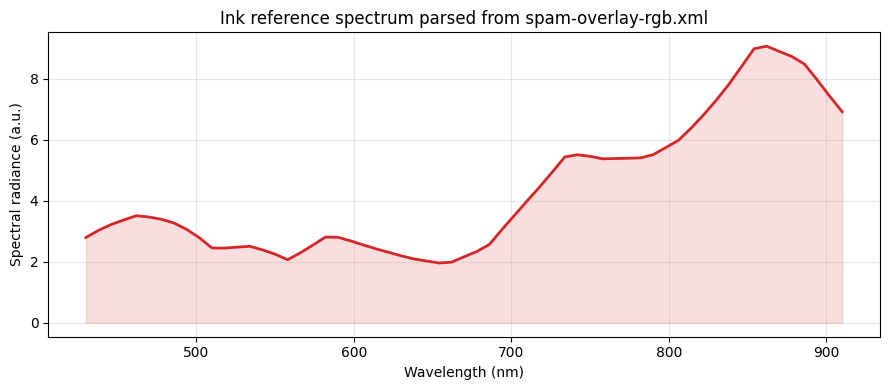

In [6]:
probe_datamodule = SingleCu3sDataModule(
    cu3s_file_path=str(active_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    predict_ids=[0],
)
probe_datamodule.setup(stage="predict")
probe_sample = probe_datamodule.predict_ds[0]
camera_wls = np.asarray(probe_sample["wavelengths"], dtype=np.float32).ravel()

bandpass_keep = (camera_wls >= sam_min_wl) & (camera_wls <= sam_max_wl)
bandpass_wls = camera_wls[bandpass_keep]
num_channels = int(bandpass_keep.sum())

if ink_spectrum.shape[1] != num_channels:
    raise RuntimeError(
        f"Reference spectrum length {ink_spectrum.shape[1]} != bandpass channels {num_channels}; "
        "XML grid does not match camera grid."
    )

print(f"XML SAM_Threshold:      {xml_threshold}")
print(f"Active SAM_Threshold:   {sam_threshold}")
print(f"Bandpass:               {sam_min_wl:.0f}–{sam_max_wl:.0f} nm")
print(f"Channels in band:       {num_channels}")
print(f"Reference spectrum NPY: {ink_reference_npy}")

plt.figure(figsize=(9, 4))
plt.plot(bandpass_wls, ink_spectrum[0], color="tab:red", linewidth=2)
plt.fill_between(bandpass_wls, ink_spectrum[0], alpha=0.15, color="tab:red")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral radiance (a.u.)")
plt.title("Ink reference spectrum parsed from spam-overlay-rgb.xml")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5 · Step A — SPAM detection + highlight overlay

Build the detection chain. Ten nodes ending at `MaskOverlayNode` — the
encoder lives in Step B, after we have a picture-in-picture composite to feed
it.

- **`CU3SDataNode`** — opens the `.cu3s`, emits `[B, H, W, C]` cubes,
  wavelengths, and a per-frame `mesu_index`.
- **`CIETristimulusRGBSelector`** — projects the cube to a normalised
  `[B, H, W, 3]` RGB frame (the visualisation base for the overlay).
  `NormMode.STATISTICAL` + a one-time sampling pass keeps brightness
  consistent across frames.
- **`BandpassByWavelength`** (×2) — restricts both the cube *and* the
  reference spectrum to the same SAM bandpass. Both `SpectralAngleMapper`
  inputs must have the same channel count, otherwise the dot product is
  undefined.
- **`NpyReader`** — streams the saved ink reference once per frame.
- **`SpectralAngleMapper`** — per-pixel `θ` against the reference. Output
  `best_scores` is `[B, H, W, 1]` in radians; `identity_mask` carries the
  best-matching reference id (here always 1, since we have one reference).
- **`ScoreToLogit`** — affine map `logit = scale·(score − bias)`. With
  `scale=−1` and `bias=1−sam_threshold`, the sign flips so *small angles
  become positive logits*. The downstream `BinaryDecider` then thresholds at
  sigmoid ≥ 0.5, which corresponds to *angle ≤ (1 − sam_threshold)*.
- **`BinaryDecider`** — sigmoid + threshold ⇒ boolean decisions
  `[B, H, W, 1]`.
- **`DecisionToMask`** — combines decisions with the SPAM identity mask into
  an int32 segmentation `[B, H, W]` (0 = background, 1 = ink).
- **`MaskRobustifier`** — morphology + connected-components filter; with
  `keep_largest=True` we keep just the biggest blob, killing speckle that
  would otherwise jitter the ROI box.
- **`MaskOverlayNode`** — alpha-blend the cleaned mask onto the RGB frame.
  Its `rgb_with_overlay` output is the *source* for Step B's inset *and*
  the *base* the inset gets composited onto.


In [7]:
pipeline = CuvisPipeline("SPAM_Active_Tracking")

cu3s_data = CU3SDataNode(name="cu3s_data")
true_rgb = CIETristimulusRGBSelector(norm_mode=NormMode.STATISTICAL, name="true_rgb")
# One-time stats pass so per-frame normalisation stays stable across the run.
initialize_false_rgb_sampled_fixed(true_rgb, probe_datamodule.predict_ds, sample_fraction=0.05)

cube_bandpass = BandpassByWavelength(
    min_wavelength_nm=sam_min_wl, max_wavelength_nm=sam_max_wl, name="cube_bandpass"
)
sig_bandpass = BandpassByWavelength(
    min_wavelength_nm=sam_min_wl, max_wavelength_nm=sam_max_wl, name="sig_bandpass"
)
ref_spectrum = NpyReader(file_path=str(ink_reference_npy), name="ref_spectrum")
spam = SpectralAngleMapper(num_channels=num_channels, name="spam")
score_to_logit = ScoreToLogit(init_scale=-1.0, init_bias=1.0 - sam_threshold, name="score_to_logit")
decider = BinaryDecider(threshold=0.5, name="decider")
to_mask = DecisionToMask(name="to_mask")
robust = MaskRobustifier(
    opening_kernel=ROBUST_OPENING,
    closing_kernel=ROBUST_OPENING,
    min_area=ROBUST_MIN_AREA,
    keep_largest=True,
    name="robust_mask",
)
overlay = MaskOverlayNode(alpha=OVERLAY_ALPHA, overlay_color=OVERLAY_COLOR, name="overlay")

# Step A wires the SPAM detection chain through the highlight burn.
# `overlay.rgb_with_overlay` is left dangling — Step B will pick it up as
# both the inset's *and* the encoder's source, so a single ToVideoNode
# writes one picture-in-picture video with the SPAM highlight + ROI inset.
pipeline.connect(
    # Hyperspectral source → RGB visualisation base
    (cu3s_data.outputs.cube, true_rgb.cube),
    (cu3s_data.outputs.wavelengths, true_rgb.wavelengths),
    # Cube + signature bandpass (same wavelength range, different sources)
    (cu3s_data.outputs.cube, cube_bandpass.data),
    (cu3s_data.outputs.wavelengths, cube_bandpass.wavelengths),
    (cu3s_data.outputs.mesu_index, ref_spectrum.frame_id),
    (ref_spectrum.data, sig_bandpass.data),
    (cu3s_data.outputs.wavelengths, sig_bandpass.wavelengths),
    # SPAM
    (cube_bandpass.filtered, spam.cube),
    (sig_bandpass.filtered, spam.spectral_signature),
    # Score → logit → decision → mask
    (spam.best_scores, score_to_logit.scores),
    (score_to_logit.logits, decider.logits),
    (decider.decisions, to_mask.decisions),
    (spam.identity_mask, to_mask.identity_mask),
    # Mask cleanup → highlight burn
    (to_mask.mask, robust.inputs.mask),
    (true_rgb.rgb_image, overlay.rgb_image),
    (robust.outputs.mask, overlay.mask),
)

### Visualize the the pipeline for SPAM detection + highlight overlay

2026-04-30 11:03:41.135 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\object_tracking_active\SPAM_Active_Tracking_stepA.png


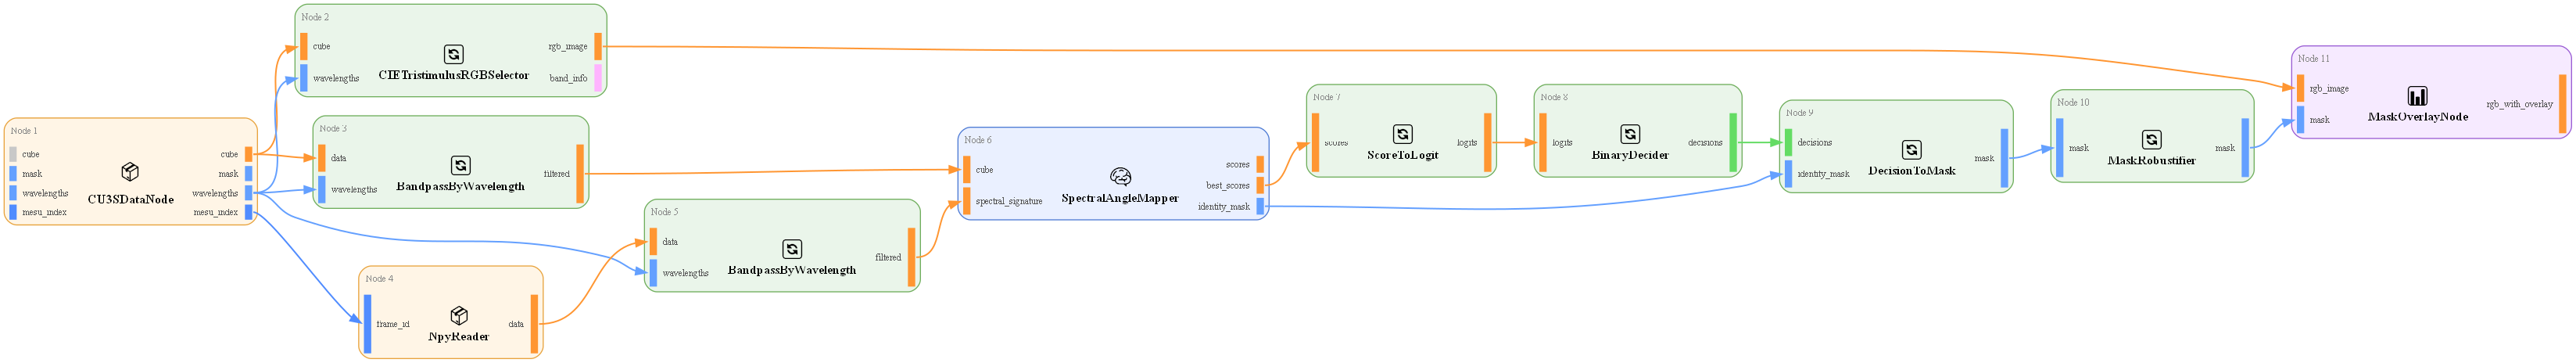

In [8]:
graph_stepA_png = pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{pipeline.name}_stepA.png"),
)
display(Image(str(graph_stepA_png)))

## 5.2 · Step B — ROI follow as a picture-in-picture inset

The overlay frame shows *where* the ink is, but a hand-held operator usually
wants a **camera that follows the marker**. Step B derives a smoothed bounding
box from the robust mask, crops a fixed-size zoom around it, and composites
that zoom into a corner of the overlay frame as an inset — a single
picture-in-picture video, no second file.

- **`MaskToBBoxKalman`** — per-frame xyxy bbox of the cleaned mask, smoothed
  through a constant-velocity Kalman filter. Quirks worth knowing:
  - `min_hits = 3` ⇒ a candidate must be measured 3 frames in a row before
    the track is "confirmed" — kills isolated false-positive flicker.
  - `max_predict_frames = 20` ⇒ once confirmed, the filter keeps predicting
    for up to 20 frames during occlusion before dropping the track.
  - Output `valid` is `1` when the frame had a measurement, `2` when only a
    Kalman prediction, `0` when the track is unconfirmed or lost.
- **`ROIZoomNode`** — crops the overlay frame around the bbox and resizes to
  `(ZOOM_SIZE, ZOOM_SIZE)`. When `valid == 0` it emits a solid background
  frame so a stale ROI never lies about the marker's position.
- **`InsetComposer`** — pastes the fixed-size zoom into a corner of the
  overlay frame with a configurable margin and border. Forwarding the same
  `valid` flag means the inset disappears (base passes through) on
  unconfirmed/lost frames.
- **`ToVideoNode`** — encodes the *composite* (overlay + inset) to
  `tracking.mp4`. One file, one stream.

> **`BBoxRoiCropNode` vs `ROIZoomNode`** — `cuvis_ai.node.preprocessors` has
> a `BBoxRoiCropNode` that uses `torchvision.ops.roi_align` and emits NCHW
> crops indexed by *number of detections*. Useful when you feed crops into a
> downstream classifier; a poor fit for per-frame video where we want one
> frame in, one frame out.


In [9]:
roi_kalman = MaskToBBoxKalman(
    min_hits=KALMAN_MIN_HITS,
    max_predict_frames=KALMAN_MAX_PREDICT,
    name="roi_kalman",
)
roi_zoom = ROIZoomNode(zoom_height=ZOOM_SIZE, zoom_width=ZOOM_SIZE, name="roi_zoom")
inset = InsetComposer(
    corner=INSET_CORNER,
    margin_px=INSET_MARGIN_PX,
    border_px=INSET_BORDER_PX,
    border_color=INSET_BORDER_COLOR,
    name="inset",
)
to_video = ToVideoNode(
    output_video_path=str(tracking_video_path),
    frame_rate=FRAME_RATE,
    name="to_video",
)

# Additive: extend the same pipeline with the ROI/compositing branch and the
# encoder. The overlay frame is consumed twice — once as the inset's source
# (cropped + zoomed) and once as the composite's base — so the final video
# carries the SPAM highlight *and* a follow-the-marker inset in one stream.
pipeline.connect(
    (robust.outputs.mask, roi_kalman.inputs.mask),
    (overlay.rgb_with_overlay, roi_zoom.source),
    (roi_kalman.bbox, roi_zoom.bbox),
    (roi_kalman.valid, roi_zoom.valid),
    (overlay.rgb_with_overlay, inset.base),
    (roi_zoom.zoom, inset.inset),
    (roi_kalman.valid, inset.valid),
    (inset.composite, to_video.rgb_image),
    (cu3s_data.outputs.mesu_index, to_video.frame_id),
)

## 5.3 · Visualize the full pipeline graph

`pipeline.visualize` renders the directed graph; useful as a sanity check
that the SPAM detection chain feeds into both the inset's source and the
composite's base, with a single `ToVideoNode` at the sink.


2026-04-30 11:03:41.591 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\object_tracking_active\SPAM_Active_Tracking.png


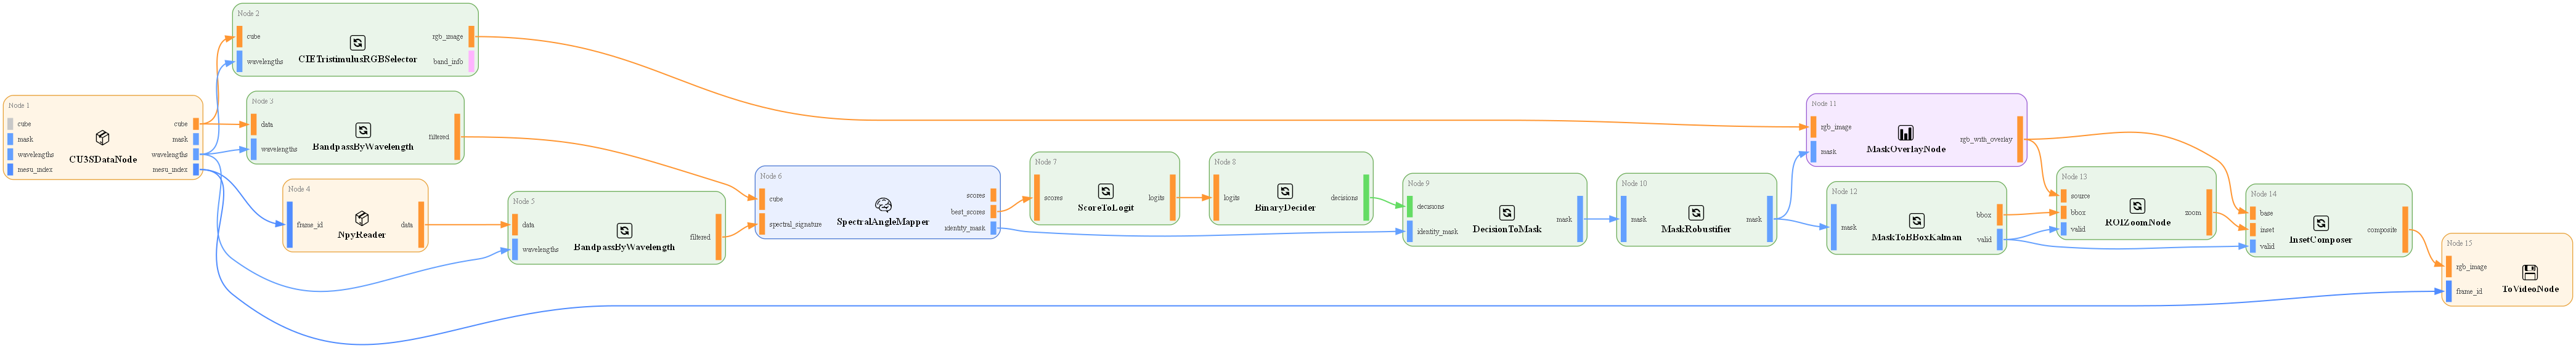

In [10]:
graph_png = pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{pipeline.name}.png"),
)
display(Image(str(graph_png)))

## 6 · Run the pipeline on a short slice

`Predictor.predict` iterates batches from `SingleCu3sDataModule` and pushes
each through the connected pipeline. The first run is capped at
`PREVIEW_END_FRAME` (default 200) so this cell finishes in ~30 s on GPU; §11
re-runs the same pipeline on the full clip.

In [11]:
preview_datamodule = SingleCu3sDataModule(
    cu3s_file_path=str(active_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    predict_ids=list(range(PREVIEW_END_FRAME)),
)

pipeline.to(device)
Predictor(pipeline=pipeline, datamodule=preview_datamodule).predict(collect_outputs=False)

if not tracking_video_path.exists():
    raise RuntimeError(f"Expected output was not created: {tracking_video_path}")

logger.success("Tracking video: {}", tracking_video_path)

ERROR:root:Last function returned 'ok'.
NoneType: None
2026-04-30 11:03:42.214 | INFO     | cuvis_ai_core.data.datasets:__init__:95 - Loaded cu3s dataset from ..\..\data\XMR_Demo_Object_Tracking\measurements\cu3s\2026_04_20_16_28_54\Auto_000.cu3s with 200 measurements: [0..199]


Predict [SPAM_Active_Tracking]:   0%|          | 0/200 [00:00<?, ?batch/s]

2026-04-30 11:04:32.294 | SUCCESS  | __main__:<module>:14 - Tracking video: output\object_tracking_active\tracking.mp4


## 9 · Watch the tracking video

One file, one stream — the SPAM highlight burns red on the marker as soon as
ink lands on the target, and the top-right inset locks on and follows it. The
inset disappears (overlay frame passes through) on unconfirmed/lost frames.


In [12]:
display(Video(str(tracking_video_path), embed=IN_COLAB, width=720))

## 10 · Tunables to experiment with

| Knob | Effect when raised | Effect when lowered |
|------|--------------------|---------------------|
| `SAM_THRESHOLD_OVERRIDE` | Tighter mask, fewer false positives, may miss sun/shade transitions on the ink | Looser mask, more false positives on confounders |
| `ROBUST_MIN_AREA` | Aggressively kills speckle, can erase tiny but real detections | Lets through more noise pixels |
| `ROBUST_OPENING` | Erodes the mask before reconstruction; useful when speckle dominates | Disabled by default (`0`) since it can erase narrow real detections |
| `KALMAN_MAX_PREDICT` | ROI persists longer through occlusion (good for brief blockers, bad for long-lost targets) | Track drops faster after a single empty frame |
| `KALMAN_MIN_HITS` | More cautious — requires longer warm-up before the inset appears | Track confirms instantly; transient false positives can briefly pop the inset |
| `OVERLAY_ALPHA` | Solid red over the marker region | Soft tint, keeps underlying texture visible |
| `ZOOM_SIZE` | Larger inset, lower effective magnification | Smaller, more zoomed |
| `INSET_CORNER` | Place the inset away from the action (`"top-right"` default; pick whichever quadrant the marker spends *least* time in) | — |
| `INSET_BORDER_PX` | Stronger inset frame; helps the eye separate inset from base scene | `0` disables the border for a flush look |
| `INSET_MARGIN_PX` | Pushes the inset further inset from the edge | Hugs the corner |


## 11 · Full-clip run

Same pipeline, every frame. Re-runs the encoder so the tracking video covers
the full clip rather than the §8 preview slice.

> **Note**: re-using the existing pipeline means the Kalman state from §8
> carries forward. Restart the kernel or rebuild the pipeline if you want a
> clean re-run from frame 0.


In [13]:
full_datamodule = SingleCu3sDataModule(
    cu3s_file_path=str(active_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    predict_ids=None,
)

pipeline.to(device)
Predictor(pipeline=pipeline, datamodule=full_datamodule).predict(collect_outputs=False)

logger.success("Tracking video: {}", tracking_video_path)

display(Video(str(tracking_video_path), embed=IN_COLAB, width=720))

ERROR:root:Last function returned 'ok'.
NoneType: None
2026-04-30 11:04:33.002 | INFO     | cuvis_ai_core.data.datasets:__init__:95 - Loaded cu3s dataset from ..\..\data\XMR_Demo_Object_Tracking\measurements\cu3s\2026_04_20_16_28_54\Auto_000.cu3s with 621 measurements: [0..620]


Predict [SPAM_Active_Tracking]:   0%|          | 0/621 [00:00<?, ?batch/s]

2026-04-30 11:06:55.353 | SUCCESS  | __main__:<module>:11 - Tracking video: output\object_tracking_active\tracking.mp4


For passive (no-ink) tracking with SAM3, see
[`uc_object_tracking.ipynb`](./uc_object_tracking.ipynb).